## Actividad 3_12
<div style="border-style:groove;border-width:thin;padding:10px">
Debes usar Random Forests para solucionar el ejercicio de MNIST. Recuerda que con Decision Tree llegamos al 87% de accuracy y con SVC llegamos al 98%. 
    </div>

In [46]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import export_graphviz
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

<div style="border-style:groove;border-width:thin;padding:10px">
A continuación vamos a importar el dataset y a generar los conjuntos X e y.
    </div>

In [47]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

<div style="border-style:groove;border-width:thin;padding:10px">
1. Divide el dataset en el conjunto de entrenamiento y de test.
    </div>

In [48]:
X, y = mnist["data"], mnist["target"]
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


<div style="border-style:groove;border-width:thin;padding:10px">
2. Crea un Random Forest con los parámetros que consideres oportuno para solucionar el problema.
    </div>

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train a Random Forest classifier
rf = RandomForestClassifier(n_estimators=700, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=700, n_jobs=-1, random_state=42)

<div style="border-style:groove;border-width:thin;padding:10px">
3. Genera la predicción (y_pred) con el árbol entrenado y mira la precisión que has conseguido. Módifica los parámetros del árbol en el código del punto 2 para mejorar los resultados.
    </div>

In [61]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Generate predictions with the trained Random Forest
y_pred = rf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9696
Accuracy Percentage: 96.96%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.99      0.99      0.99      1600
           2       0.95      0.97      0.96      1380
           3       0.96      0.95      0.96      1433
           4       0.97      0.97      0.97      1295
           5       0.98      0.97      0.97      1273
           6       0.98      0.99      0.98      1396
           7       0.97      0.97      0.97      1503
           8       0.96      0.96      0.96      1357
           9       0.96      0.95      0.95      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



<div style="border-style:groove;border-width:thin;padding:10px">
4. Recorre la muestra de test viendo los datos que son erróneos y muestra la imagen. Evalúa si el resultado es suficientemente bueno.
</div>

📊 ANÁLISIS DE ERRORES DEL ÁRBOL DE DECISIÓN
Total de muestras de test: 14000
Total de errores: 426
Tasa de error: 3.04%
Tasa de acierto: 96.96%


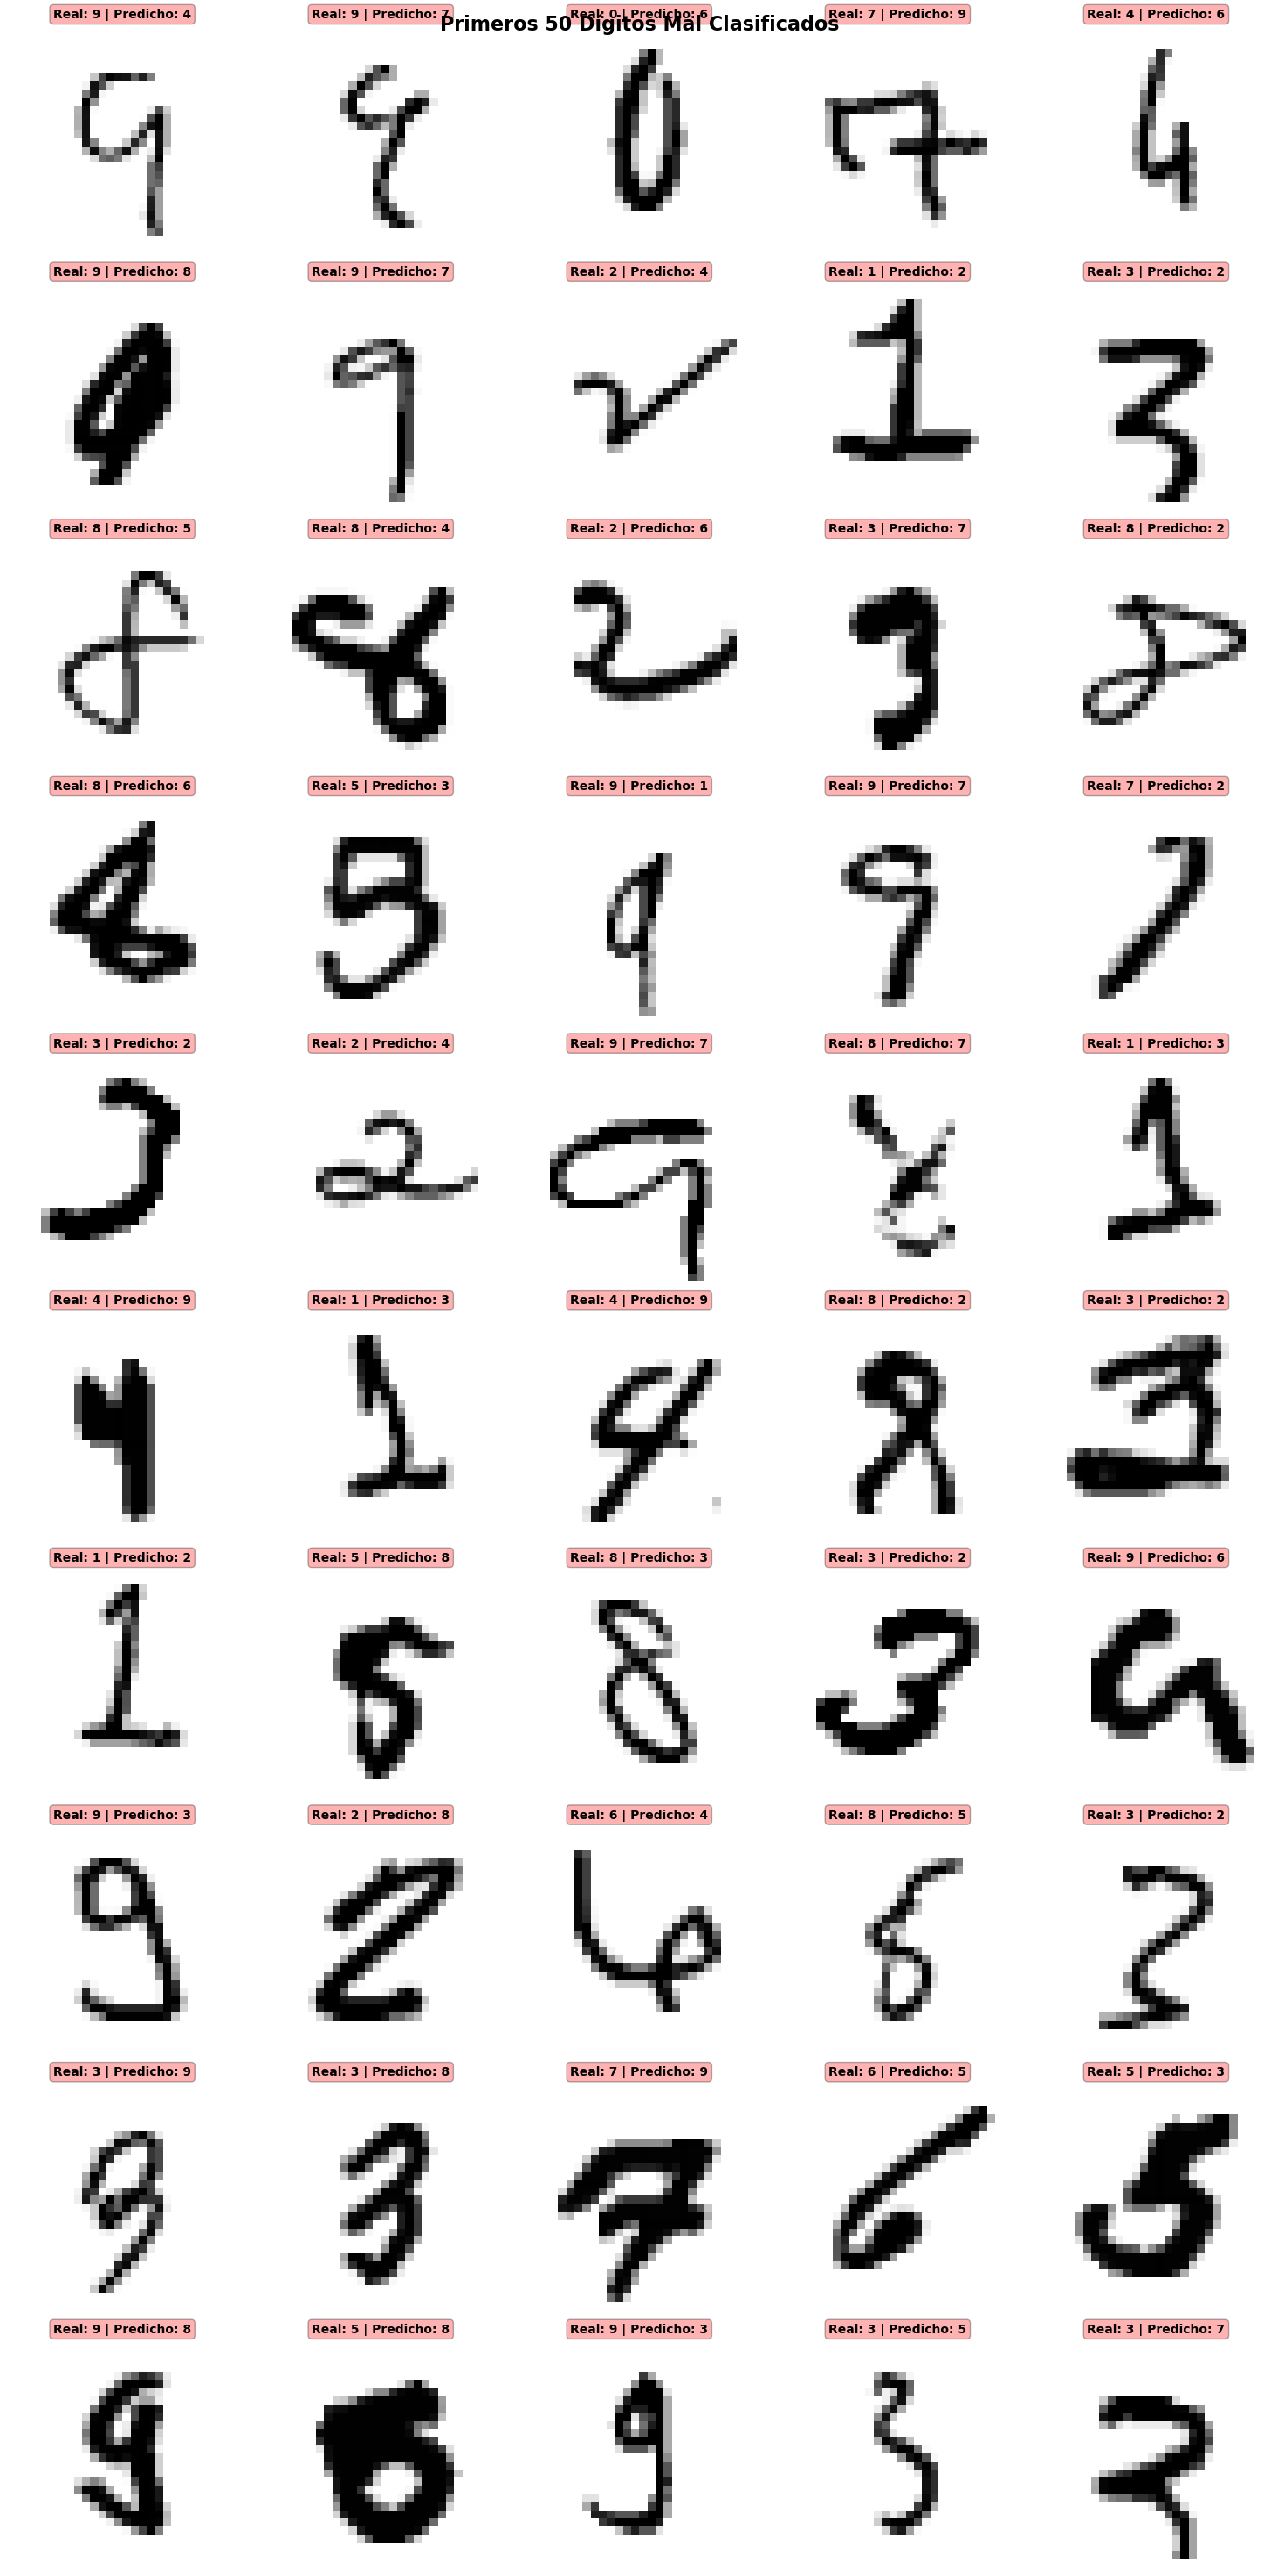


📈 ANÁLISIS DETALLADO DE CONFUSIONES:
--------------------------------------------------------------------------------

Top 10 confusiones más frecuentes:
   1. Dígito 4 predicho como 9:  27 veces
   2. Dígito 3 predicho como 2:  24 veces
   3. Dígito 7 predicho como 2:  18 veces
   4. Dígito 9 predicho como 4:  16 veces
   5. Dígito 7 predicho como 9:  16 veces
   6. Dígito 8 predicho como 3:  15 veces
   7. Dígito 5 predicho como 3:  14 veces
   8. Dígito 9 predicho como 3:  14 veces
   9. Dígito 3 predicho como 7:  13 veces
  10. Dígito 9 predicho como 7:  12 veces

📋 EVALUACIÓN DEL RESULTADO:
✅ Accuracy: 0.9696 (96.96%)

📊 Clasificación por dígito:               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.99      0.99      0.99      1600
           2       0.95      0.97      0.96      1380
           3       0.96      0.95      0.96      1433
           4       0.97      0.97      0.97      1295
           5  

In [57]:
# Encontrar índices de errores
errors = y_test != y_pred
error_indices = np.where(errors)[0]

print(f"📊 ANÁLISIS DE ERRORES DEL ÁRBOL DE DECISIÓN")
print("=" * 80)
print(f"Total de muestras de test: {len(y_test)}")
print(f"Total de errores: {len(error_indices)}")
print(f"Tasa de error: {len(error_indices)/len(y_test)*100:.2f}%")
print(f"Tasa de acierto: {(1 - len(error_indices)/len(y_test))*100:.2f}%")
print("=" * 80)

# Número de errores a mostrar (configurable)
num_errors_to_show = min(50, len(error_indices))  # Cambiar 20 por el número que quieras

# Calcular dimensiones de la grid
cols = 5
rows = (num_errors_to_show + cols - 1) // cols  # Redondear hacia arriba

fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
fig.suptitle(f'Primeros {num_errors_to_show} Dígitos Mal Clasificados', 
             fontsize=16, fontweight='bold')

# Aplanar axes si es necesario
if rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

for i, idx in enumerate(error_indices[:num_errors_to_show]):
    # Obtener la imagen
    digit_image = X_test.iloc[idx].values.reshape(28, 28)
    
    # Plotear
    axes[i].imshow(digit_image, cmap="binary")
    axes[i].axis("off")
    
    # Título con predicción vs real
    true_label = int(y_test.iloc[idx])
    pred_label = int(y_pred[idx])
    
    title = f"Real: {true_label} | Predicho: {pred_label}"
    axes[i].set_title(title, fontsize=10, fontweight='bold', 
                      bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

# Ocultar axes sobrantes si existen
for i in range(num_errors_to_show, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Análisis detallado de confusiones
print("\n📈 ANÁLISIS DETALLADO DE CONFUSIONES:")
print("-" * 80)

# Mostrar pares de confusión más comunes
from collections import Counter
confusion_pairs = []

for idx in error_indices:
    true_label = int(y_test.iloc[idx])
    pred_label = int(y_pred[idx])
    confusion_pairs.append((true_label, pred_label))

most_common_confusions = Counter(confusion_pairs).most_common(10)

print("\nTop 10 confusiones más frecuentes:")
for i, ((true_label, pred_label), count) in enumerate(most_common_confusions, 1):
    print(f"  {i:2}. Dígito {true_label} predicho como {pred_label}: {count:3} veces")

# Evaluación general
print("\n" + "=" * 80)
print("📋 EVALUACIÓN DEL RESULTADO:")
print("=" * 80)

accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print("\n📊 Clasificación por dígito: {}".format(classification_report(y_test, y_pred)))